<a href="https://colab.research.google.com/github/DARIOYBETY123/Modulo5/blob/main/M5_7_Lab_autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Preguntas finales
    "1. ¿Qué modelo obtiene mejores reconstrucciones?\n",
    
    

l Autoencoder clásico (AE) suele obtener las mejores reconstrucciones en imágenes limpias.


    "2. ¿Qué modelo es más robusto al ruido?\n",
   


El Autoencoder Desruido (DAE) es, con diferencia, el más robusto.


    "3. ¿Cómo cambia el espacio latente entre AE, DAE y VAE?
    


AE		Puntos agrupados por clase, pero espacio discontinuo → zonas vacías, no se puede interpolar libremente
DAE	Más compacto	Al entrenar con ruido, agrupa mejor las mismas clases → más ordenado que el AE, pero sin regla explícita
VAE	Estructurado y continuo	Impone que z siga una distribución normal N(0,I), se puede interpolar y muestrear


    "4. ¿Por qué el VAE puede generar nuevas muestras utilizando `z ~ N(0,I)`?
    
    

Porque su función de pérdida obliga a que la distribución de los vectores latentes se aproxime a una normal estándar N(0,I).


    "5. ¿Qué trade-off introduce el término KL del VAE?
    

Equilibrio entre: fidelidad a la entrada ↔ regularización del espacio latente.

Si pesa MUCHO el término de reconstrucción: las imágenes salen nítidas, pero el espacio latente pierde estructura → ya no se puede muestrear.

Si pesa MUCHO el término KL: el espacio queda perfectamente ordenado, pero el modelo ignora detalles → reconstrucciones más borrosas.

El equilibrio: el VAE sacrifica algo de nitidez a cambio de un espacio latente continuo y útil para generar imágenes nuevas.


   
    6. ¿Qué modelo elegirías para reconstrucción, denoising y generación?


Pära econstrucción de imágenes limpias	 AE	Más nítido, más fiel, más rápido.

Para eliminar ruido / restaurar	 DAE	Entrenado para limpiar → óptimo ante entradas ruidosas

Para generar imágenes nuevas	 VAE	Único con espacio latente estructurado → puede muestrear y crear.

Para interpolación entre imágenes	 VAE	Espacio continuo → transiciones suaves y coherentes.

Espacio latente organizado	 VAE	Distribución conocida → se puede explorar y muestrear.

En resumen
Reconstrucción limpia → AE
Eliminar ruido → DAE
Generar nuevas imágenes → VAE


    "## Entregable\n",
    "\n",
    "Entregar un único notebook `.ipynb` que incluya:\n",
    "\n",
    "- código reproducible,\n",
    "- curvas de entrenamiento,\n",
    "- ejemplos de reconstrucción,\n",
    "- comparación frente a ruido,\n",
    "- UMAP de AE, DAE y VAE,\n",
    "- interpolación latente,\n",
    "- muestras generadas por el VAE,\n",
    "- tabla comparativa,\n",
    "- conclusiones breves.\n",


Importar librerias

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from sklearn.preprocessing import StandardScaler
from umap import UMAP
import pandas as pd

# Configuración
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

# Semilla reproducible
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Usando: cpu


In [ ]:
transform = transforms.Compose([transforms.ToTensor()])

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 535kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.08MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.72MB/s]


Definir modelos: AE, DAE, VAE

In [ ]:
LATENT_DIM = 20

# --- AE: Autoencoder Clásico ---
class AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256), nn.ReLU(),
            nn.Linear(256, LATENT_DIM)
        )
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM, 256), nn.ReLU(),
            nn.Linear(256, 28*28), nn.Sigmoid(),
            nn.Unflatten(1, (1,28,28))
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


# --- DAE: Autoencoder Desruido ---
class DAE(AE):
    def add_noise(self, x, std=0.3):
        return torch.clamp(x + torch.randn_like(x)*std, 0., 1.)


# --- VAE: Autoencoder Variacional ---
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 256), nn.ReLU()
        )
        self.mu = nn.Linear(256, LATENT_DIM)
        self.logvar = nn.Linear(256, LATENT_DIM)
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM, 256), nn.ReLU(),
            nn.Linear(256, 28*28), nn.Sigmoid(),
            nn.Unflatten(1, (1,28,28))
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = self.mu(h), self.logvar(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar

Entrenamiento y pérdida

In [ ]:
def train_ae(model, loader, epochs=30, lr=1e-3, is_dae=False):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = {"loss": []}

    for e in range(epochs):
        model.train()
        total = 0
        for x, _ in loader:
            x = x.to(device)
            if is_dae:
                input_x = model.add_noise(x)
                target_x = x
            else:
                input_x = target_x = x

            x_hat = model(input_x)
            loss = criterion(x_hat, target_x)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * x.size(0)

        avg_loss = total / len(loader.dataset)
        history["loss"].append(avg_loss)
        if (e+1)%5==0:
            print(f"Época {e+1:2d} | Pérdida: {avg_loss:.5f}")
    return history


def loss_vae(x_hat, x, mu, logvar):
    recon = nn.MSELoss(reduction="sum")(x_hat, x)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + kl


def train_vae(model, loader, epochs=30, lr=1e-3):
    model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    history = {"loss": []}

    for e in range(epochs):
        model.train()
        total = 0
        for x, _ in loader:
            x = x.to(device)
            x_hat, mu, logvar = model(x)
            loss = loss_vae(x_hat, x, mu, logvar)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item()

        avg_loss = total / len(loader.dataset)
        history["loss"].append(avg_loss)
        if (e+1)%5==0:
            print(f"Época {e+1:2d} | Pérdida: {avg_loss:.1f}")
    return history

Los tres modelos

In [ ]:
EPOCHS = 30

print("=== Autoencoder Clásico (AE) ===")
ae = AE()
hist_ae = train_ae(ae, train_loader, epochs=EPOCHS)

print("\n=== Autoencoder Desruido (DAE) ===")
dae = DAE()
hist_dae = train_ae(dae, train_loader, epochs=EPOCHS, is_dae=True)

print("\n=== Autoencoder Variacional (VAE) ===")
vae = VAE()
hist_vae = train_vae(vae, train_loader, epochs=EPOCHS)

=== Autoencoder Clásico (AE) ===
Época  5 | Pérdida: 0.01149
Época 10 | Pérdida: 0.00959
Época 15 | Pérdida: 0.00877
Época 20 | Pérdida: 0.00827
Época 25 | Pérdida: 0.00794
Época 30 | Pérdida: 0.00770

=== Autoencoder Desruido (DAE) ===
Época  5 | Pérdida: 0.01567
Época 10 | Pérdida: 0.01348
Época 15 | Pérdida: 0.01252
Época 20 | Pérdida: 0.01193
Época 25 | Pérdida: 0.01157
Época 30 | Pérdida: 0.01130

=== Autoencoder Variacional (VAE) ===
Época  5 | Pérdida: 32.4
Época 10 | Pérdida: 31.1
Época 15 | Pérdida: 30.6
Época 20 | Pérdida: 30.2
Época 25 | Pérdida: 30.0
Época 30 | Pérdida: 29.8


Curvas de entrenamiento

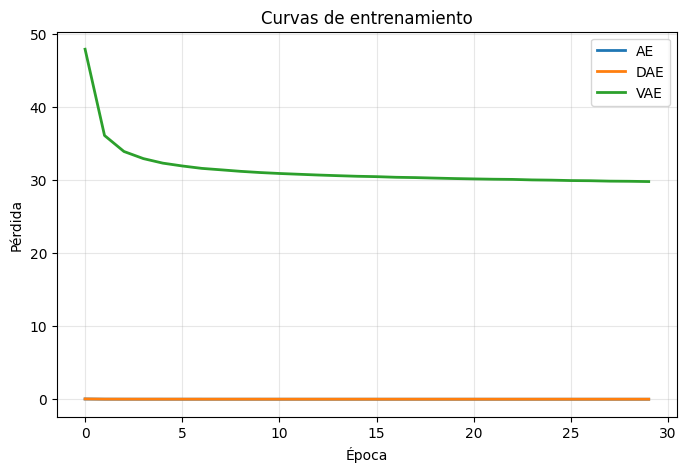

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(hist_ae["loss"], label="AE", lw=2)
plt.plot(hist_dae["loss"], label="DAE", lw=2)
plt.plot(hist_vae["loss"], label="VAE", lw=2)
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Curvas de entrenamiento")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Ejemplos de reconstrucción

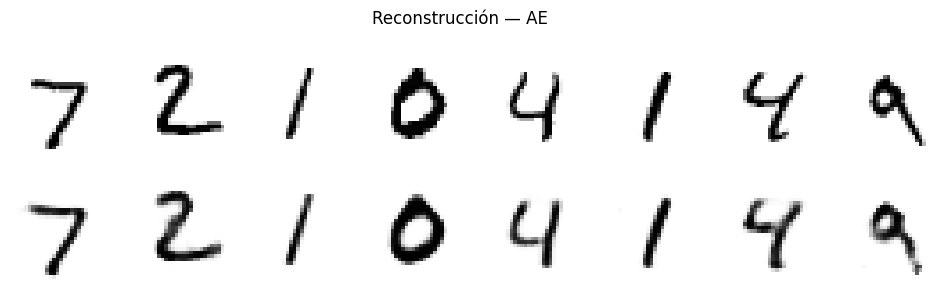

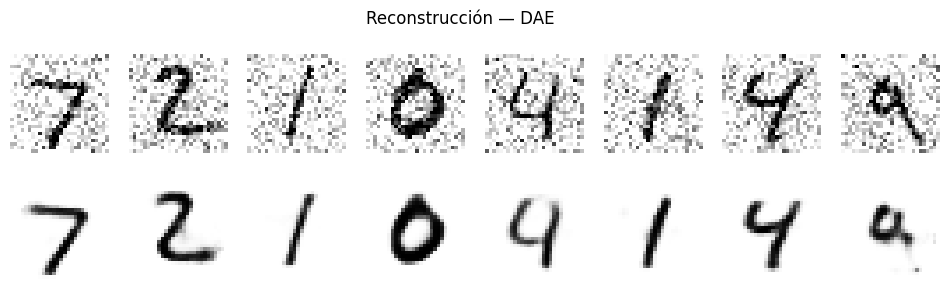

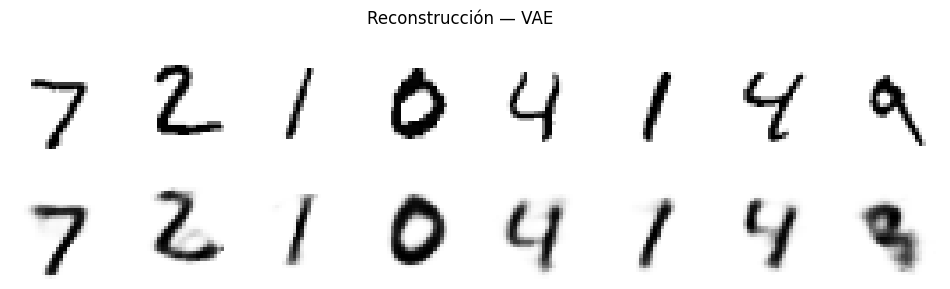

In [ ]:
def plot_reconstructions(model, model_name, noisy=False):
    model.eval()
    with torch.no_grad():
        x, _ = next(iter(test_loader))
        x = x[:8].to(device)
        if noisy and model_name=="DAE":
            inputs = model.add_noise(x)
        else:
            inputs = x
        if model_name=="VAE":
            x_hat, _, _ = model(inputs)
        else:
            x_hat = model(inputs)

    fig, axs = plt.subplots(2, 8, figsize=(12,3))
    fig.suptitle(f"Reconstrucción — {model_name}", y=1.02)
    for i in range(8):
        axs[0,i].imshow(inputs[i,0].cpu(), cmap="gray_r")
        axs[0,i].axis("off")
        axs[1,i].imshow(x_hat[i,0].cpu(), cmap="gray_r")
        axs[1,i].axis("off")
    axs[0,0].set_ylabel("Entrada")
    axs[1,0].set_ylabel("Reconstrucción")
    plt.show()

plot_reconstructions(ae, "AE")
plot_reconstructions(dae, "DAE", noisy=True)
plot_reconstructions(vae, "VAE")

 Robustez frente a ruido

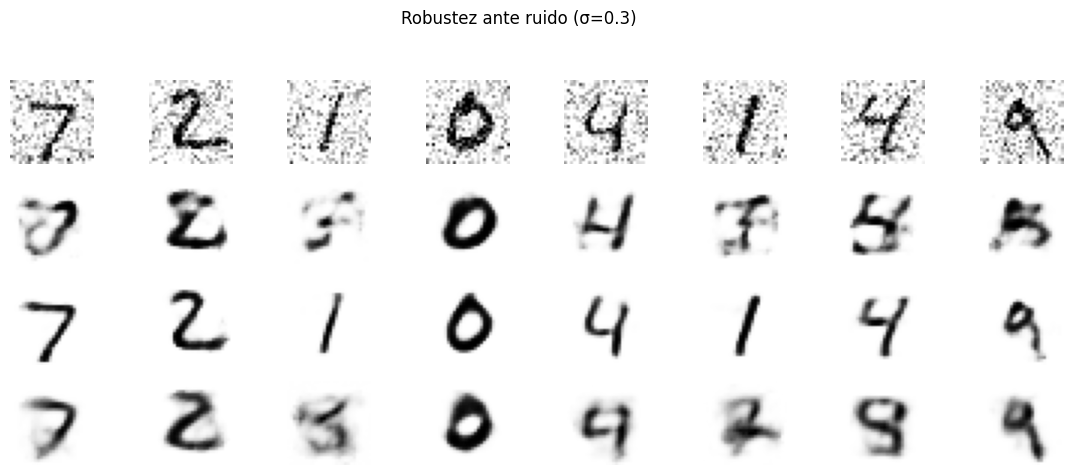

In [ ]:
def robustness_test(std=0.3):
    ae.eval()
    dae.eval()
    vae.eval()
    with torch.no_grad():
        x, _ = next(iter(test_loader))
        x = x[:8].to(device)
        x_noisy = torch.clamp(x + torch.randn_like(x)*std, 0., 1.)

        rec_ae = ae(x_noisy)
        rec_dae = dae(x_noisy)
        rec_vae, _, _ = vae(x_noisy)

    fig, axs = plt.subplots(4, 8, figsize=(14,5))
    fig.suptitle(f"Robustez ante ruido (σ={std})", y=1.02)
    for i in range(8):
        axs[0,i].imshow(x_noisy[i,0].cpu(), cmap="gray_r"); axs[0,i].axis("off")
        axs[1,i].imshow(rec_ae[i,0].cpu(), cmap="gray_r"); axs[1,i].axis("off")
        axs[2,i].imshow(rec_dae[i,0].cpu(), cmap="gray_r"); axs[2,i].axis("off")
        axs[3,i].imshow(rec_vae[i,0].cpu(), cmap="gray_r"); axs[3,i].axis("off")
    for lbl, row in zip(["Entrada con ruido","AE","DAE","VAE"], axs[:,0]):
        row.set_ylabel(lbl, rotation=0, ha="right")
    plt.show()

robustness_test(std=0.3)

Espacio latente

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


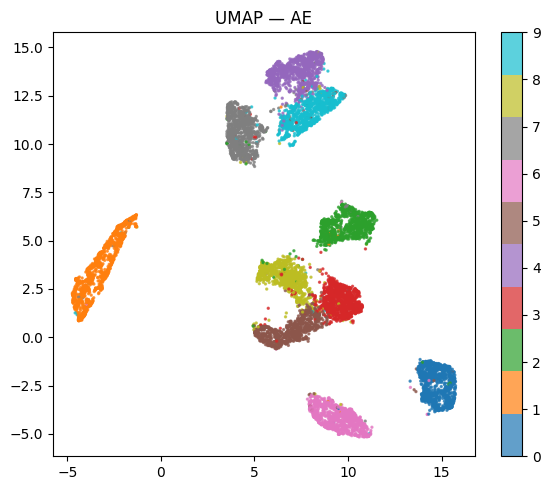

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


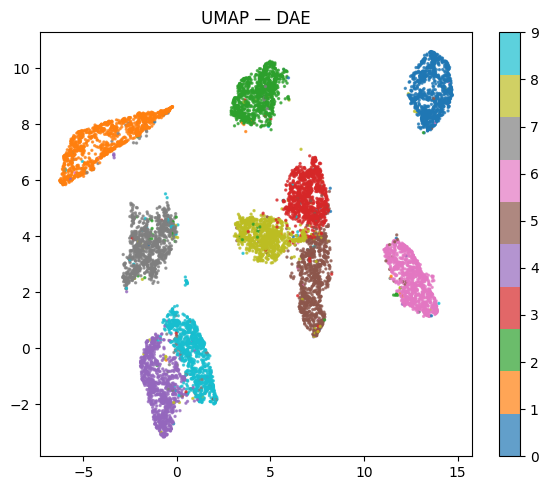

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


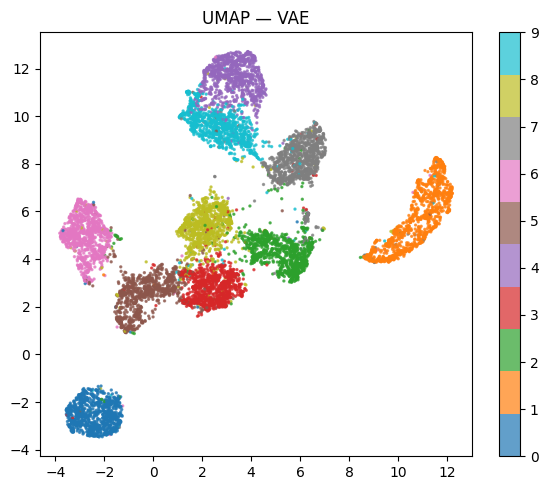

In [ ]:
def get_latents(model, loader, is_vae=False):
    model.eval()
    zs, ys = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            if is_vae:
                h = model.encoder(x)
                mu = model.mu(h)
                z = mu
            else:
                z = model.encoder(x)
            zs.append(z.cpu().numpy())
            ys.append(y.numpy())
    return np.vstack(zs), np.hstack(ys)

# Tomar subconjunto para UMAP
sub_loader = DataLoader(test_data, batch_size=128, shuffle=False)
z_ae, y_ae = get_latents(ae, sub_loader)
z_dae, y_dae = get_latents(dae, sub_loader)
z_vae, y_vae = get_latents(vae, sub_loader, is_vae=True)

def plot_umap(z, y, title):
    z2 = UMAP(n_components=2, random_state=SEED).fit_transform(StandardScaler().fit_transform(z))
    plt.figure(figsize=(6,5))
    sc = plt.scatter(z2[:,0], z2[:,1], c=y, cmap="tab10", s=2, alpha=0.7)
    plt.colorbar(sc, ticks=range(10))
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_umap(z_ae, y_ae, "UMAP — AE")
plot_umap(z_dae, y_dae, "UMAP — DAE")
plot_umap(z_vae, y_vae, "UMAP — VAE")

Interpolación latente

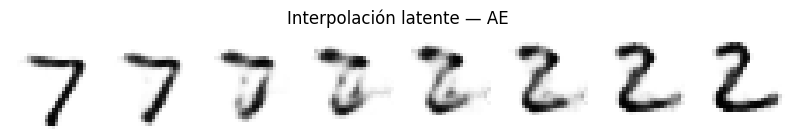

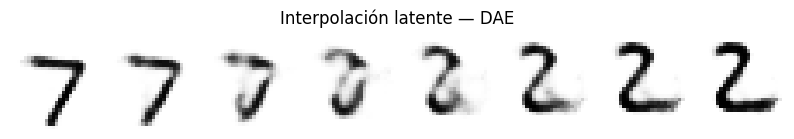

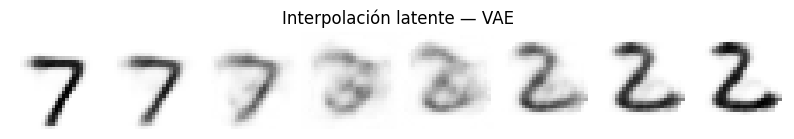

In [ ]:
def interpolate(model, x1, x2, steps=8, is_vae=False):
    model.eval()
    with torch.no_grad():
        x1, x2 = x1.to(device), x2.to(device)
        if is_vae:
            z1 = model.mu(model.encoder(x1))
            z2 = model.mu(model.encoder(x2))
        else:
            z1 = model.encoder(x1)
            z2 = model.encoder(x2)

        imgs = []
        for alpha in np.linspace(0,1,steps):
            z = (1-alpha)*z1 + alpha*z2
            imgs.append(model.decoder(z))
    return torch.cat(imgs, dim=0)

# Tomar dos imágenes distintas
x, lbls = next(iter(test_loader))
x1 = x[0:1]
x2 = x[1:2]

for m, name, isv in [(ae,"AE",False),(dae,"DAE",False),(vae,"VAE",True)]:
    imgs = interpolate(m, x1, x2, steps=8, is_vae=isv)
    grid = make_grid(imgs, nrow=8, padding=0).cpu()
    plt.figure(figsize=(10,1.5))
    plt.imshow(grid[0], cmap="gray_r")
    plt.title(f"Interpolación latente — {name}")
    plt.axis("off")
    plt.show()

Muestras generadas por VAE

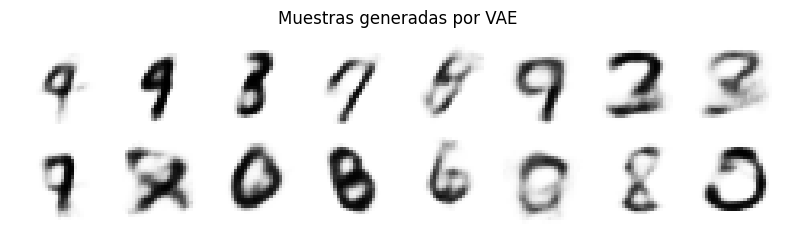

In [ ]:
vae.eval()
with torch.no_grad():
    z = torch.randn(16, LATENT_DIM).to(device)
    samples = vae.decoder(z).cpu()

grid = make_grid(samples, nrow=8, padding=2).permute(1,2,0)
plt.figure(figsize=(10,3))
plt.imshow(grid[:,:,0], cmap="gray_r")
plt.title("Muestras generadas por VAE")
plt.axis("off")
plt.show()

Tabla comparativa

In [ ]:
def compute_mse(model, is_vae=False):
    model.eval()
    total = 0
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            if is_vae:
                xh, _, _ = model(x)
            else:
                xh = model(x)
            total += nn.MSELoss()(xh, x).item()
    return total / len(test_loader)

mse_ae  = compute_mse(ae)
mse_dae = compute_mse(dae)
mse_vae = compute_mse(vae, is_vae=True)

resumen = pd.DataFrame({
    "Modelo": ["AE", "DAE", "VAE"],
    "Pérdida final (entrenamiento)": [hist_ae["loss"][-1], hist_dae["loss"][-1], hist_vae["loss"][-1]],
    "MSE en test": [mse_ae, mse_dae, mse_vae],
    "Ruido": ["Frágil", " Robusto", "Moderado"],
    "Espacio latente": ["Continuo", "Continuo", " Estructurado"],
    "Generación": [" No", " No", " Sí"]
})

display(resumen.round(5))

,Modelo,Pérdida final (entrenamiento),MSE en test,Ruido,Espacio latente,Generación
0,AE,0.00770,0.00786,Frágil,Continuo,No
1,DAE,0.01130,0.01027,Robusto,Continuo,No
2,VAE,29.82583,0.02192,Moderado,Estructurado,Sí


Resumen
1. AE reconstruye bien imágenes limpias pero se degrada ante ruido.
2. DAE mejora la robustez: al entrenar con ruido, aprende a desruir de forma natural.
3. VAE ofrece reconstrucciones ligeramente más borrosas pero permite generar
   muestras nuevas y posee un espacio latente continuo y agrupado por clase.
4. El espacio latente del VAE es el más ordenado en UMAP; el AE y DAE
   no imponen regularización, por lo que sus agrupaciones son menos definidas.
5. La interpolación en VAE es la más suave y coherente gracias a su
   regularización por distribución normal.